In [1]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *

print("Fixed Income Library is loaded.")

Added to sys.path:/ /Users/leo/Leo/Risk_topic/FRE-GT-9743-Assignment-8
Fixed Income Library is loaded.


# 1. SABR Conversion

The SABR model is a stochastic volatility model developed by Hagan et al. The dynamics of the forward rate \(F(t)\) are:

$
dF(t)=\sigma(t)F^\beta(t)dW_1(t)
$

$
d\sigma(t)=\nu\sigma(t)dW_2(t)
$

$
dW_1 dW_2 = \rho dt
$

with initial conditions:

$
F(0)=F_0
$

$
\sigma(0)=\alpha
$

---

Using asymptotic expansion techniques, the equivalent Black volatility can be written as:

$
\sigma_{LN}^{B} =
\frac{\alpha}{(FK)^{(1-\beta)/2}}
\frac{z}{x(z)}
\omega_1
\left(1+\omega_2 T + \cdots \right)
$

---

### Definitions

$
z =
\frac{\nu}{\alpha}
(FK)^{(1-\beta)/2}
\log(F/K)
$

$
x(z) =
\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)
$

$
\omega_1 =
1+
\frac{(1-\beta)^2}{24}\log^2(F/K)
+
\frac{(1-\beta)^4}{1920}\log^4(F/K)
+\cdots
$

$
\omega_2 =
\frac{(1-\beta)^2}{24}
\frac{\alpha^2}{(FK)^{1-\beta}}
+
\frac{1}{4}
\frac{\alpha\beta\rho\nu}{(FK)^{(1-\beta)/2}}
+
\frac{2-3\rho^2}{24}\nu^2
$

---

## Hagan's formula expansion around ATM

Notice that:

$
\frac{z}{x}=
\frac{z}
{\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)}
$

This expression becomes indeterminate at \(z=0\), which corresponds to:

$
K=F
$

For small $z$, we use a Taylor expansion:

$
\frac{z}{x}
\approx 1
-\frac{1}{2}\rho z +
\left(
-\frac{1}{4}\rho^2+\frac{1}{6}
\right)z^2 -
\left(
\frac{1}{4}\rho^2-\frac{5}{24}
\right)\rho z^3+
\left(
-\frac{5}{16}\rho^4
+\frac{1}{3}\rho^2
-\frac{17}{360}
\right)z^4-
\left(
\frac{7}{16}\rho^4
-\frac{55}{96}\rho^2
+\frac{37}{240}
\right)\rho z^5
$

This expansion is typically sufficient when:

$
|z|<0.01
$

---

When the strike is very close to zero or very large, the density derived from the equivalent Black volatility may become negative or unstable. This motivates corrections to the wings of the Hagan expansion.

According to the readings above, please complete the functions referenced in `sabr.py`.

You may use the API provided above to implement both the volatility and risk functions. After that, run the code blocks below.

In [2]:
# utilities
def display_res(input_dict: Dict[SimpleMetrics, float]):
    display({k.to_string(): v for k, v in input_dict.items()})

In [3]:
### hagan's classic formula
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5

res_imp_log_normal_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, strike, tte, alpha, beta, rho, nu, shift, True
)
display_res(res_imp_log_normal_vol)

{'implied_log_normal_vol': np.float64(0.3075362081997875),
 'd_ln_sigma_d_alpha': np.float64(9.051526234839306),
 'd_ln_sigma_d_beta': np.float64(-2.4947233069049926),
 'd_ln_sigma_d_rho': np.float64(0.015606211717868926),
 'd_ln_sigma_d_nu': np.float64(0.0578448084635778),
 'd_ln_sigma_d_forward': np.float64(-7.805814513634762),
 'd_ln_sigma_d_strike': np.float64(2.7585122775347988),
 'd_ln_sigma_d_tte': 0.024590290064112556}

In [4]:
eps = 1e-6
vol_base = qfEuropeanOptionSABRLogNormalSigma(forward, strike, tte, alpha,     beta, rho, nu, shift, False)
vol_up   = qfEuropeanOptionSABRLogNormalSigma(forward, strike, tte, alpha+eps, beta, rho, nu, shift, False)

print("base:", vol_base[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL])
print("up:  ", vol_up[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL])

numerical_dalpha = (
    vol_up[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL] 
    - vol_base[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL]
) / eps / vol_base[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL]
print(numerical_dalpha)

base: 0.3075362081997875
up:   0.3075389918720121
9.05152678089575


# 2. Detection of Negative Density

The parameters set is:

In [5]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

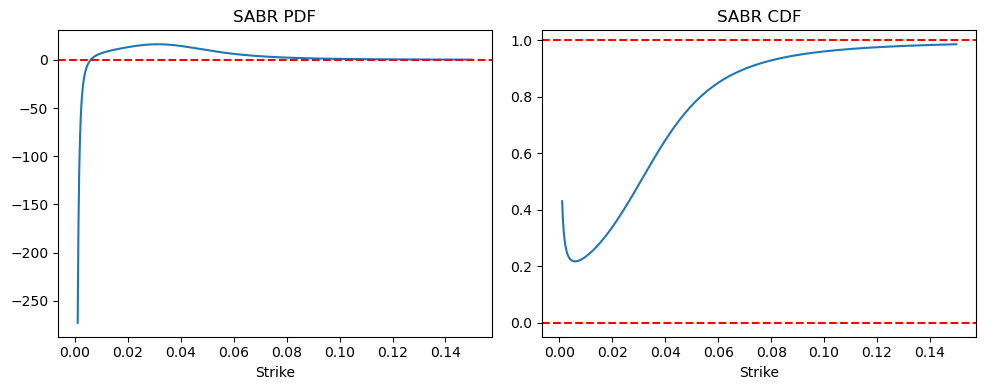

Negative density detected between K=0.0010 and K=0.0058


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
strikes = np.linspace(0.001, 0.15, 500)

pdf, cdf = SABRAnalytics.pdf_and_cdf(
    forward, tte, alpha, beta, rho, nu, strikes, shift
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(strikes, pdf)
plt.axhline(0, color='r', linestyle='--')
plt.title('SABR PDF')
plt.xlabel('Strike')

plt.subplot(1, 2, 2)
plt.plot(strikes, cdf)
plt.axhline(0, color='r', linestyle='--')
plt.axhline(1, color='r', linestyle='--')
plt.title('SABR CDF')
plt.xlabel('Strike')

plt.tight_layout()
plt.show()

neg_strikes = strikes[pdf < 0]
if len(neg_strikes) > 0:
    print(f"Negative density detected between K={neg_strikes[0]:.4f} and K={neg_strikes[-1]:.4f}")
else:
    print("No negative density detected")


# 3. SABR Simulation and Density

For bump-and-revaluation calculations, please use the functions provided in `european_options.py`.

If an analytical solution is preferred, the corresponding implementation can be found in `sabr.py`.

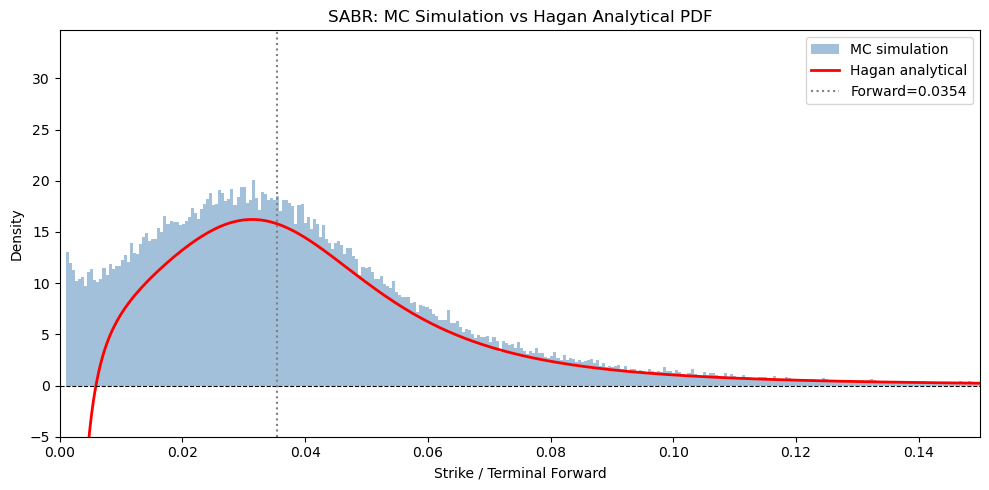

MC mean:   0.035724 (should be ≈ 0.035400)
MC std:    0.037382
% paths ≤ 0: 4.98%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.0512
beta  = 0.5
nu    = 0.322
rho   = -9.5/100
shift = 0.0
forward = 3.54/100
tte   = 10

n_paths = 100_000
n_steps = 252 * tte      
dt      = tte / n_steps

rng = np.random.default_rng(42)
Z1  = rng.standard_normal((n_steps, n_paths))
Z2  = rho * Z1 + np.sqrt(1 - rho**2) * rng.standard_normal((n_steps, n_paths))

F = np.full(n_paths, forward)
s = np.full(n_paths, alpha)     

for i in range(n_steps):
    F_pos = np.maximum(F, 1e-10)   
    dF    = s * F_pos**beta * np.sqrt(dt) * Z1[i]
    ds    = nu * s * np.sqrt(dt) * Z2[i]
    F     = F_pos + dF
    s     = s + ds
    s     = np.maximum(s, 1e-10)   

strikes = np.linspace(0.001, 0.15, 500)
pdf_hagan, _ = SABRAnalytics.pdf_and_cdf(
    forward, tte, alpha, beta, rho, nu, strikes, shift
)

plt.figure(figsize=(10, 5))


plt.hist(F, bins=300, density=True, range=(0.001, 0.15),alpha=0.5, label='MC simulation', color='steelblue')

plt.plot(strikes, pdf_hagan, 'r-', linewidth=2, label='Hagan analytical')

plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axvline(forward, color='gray', linestyle=':', label=f'Forward={forward:.4f}')
plt.xlabel('Strike / Terminal Forward')
plt.ylabel('Density')
plt.title('SABR: MC Simulation vs Hagan Analytical PDF')
plt.legend()
plt.xlim(0, 0.15)
plt.ylim(-5, None)
plt.tight_layout()
plt.show()

print(f"MC mean:   {F.mean():.6f} (should be ≈ {forward:.6f})")
print(f"MC std:    {F.std():.6f}")
print(f"% paths ≤ 0: {(F <= 0).mean()*100:.2f}%")

# 4. Quantile Map


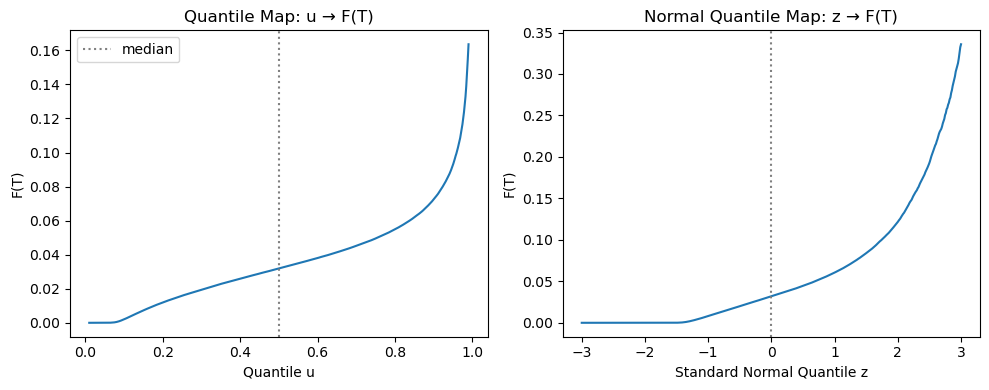

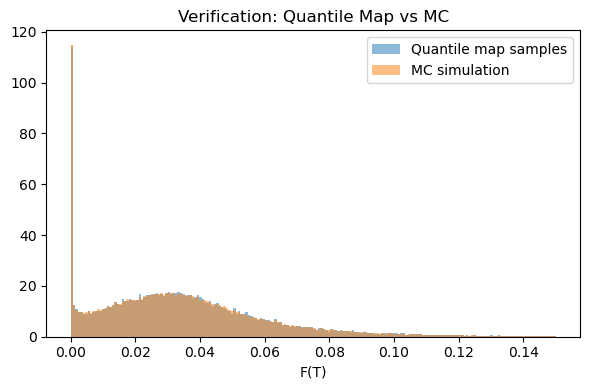

Quantile map mean:   0.037757
Quantile map median: 0.032044
MC median:           0.031900


In [8]:
from scipy.interpolate import interp1d
from scipy.stats import norm

F_pos = np.sort(F[F > 0])
cdf_mc = np.arange(1, len(F_pos) + 1) / len(F_pos)   

quantile_map = interp1d(cdf_mc, F_pos, bounds_error=False, fill_value=(F_pos[0], F_pos[-1]))

u = np.linspace(0.01, 0.99, 500)
Q = quantile_map(u)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(u, Q)
plt.xlabel('Quantile u')
plt.ylabel('F(T)')
plt.title('Quantile Map: u → F(T)')
plt.axvline(0.5, color='gray', linestyle=':', label='median')
plt.legend()

plt.subplot(1, 2, 2)
z = np.linspace(-3, 3, 500)
u_from_z = norm.cdf(z)
Q_from_z = quantile_map(u_from_z)

plt.plot(z, Q_from_z)
plt.xlabel('Standard Normal Quantile z')
plt.ylabel('F(T)')
plt.title('Normal Quantile Map: z → F(T)')
plt.axvline(0, color='gray', linestyle=':')
plt.tight_layout()
plt.show()

u_samples = rng.uniform(0, 1, 100_000)
F_quantile = quantile_map(u_samples)

plt.figure(figsize=(6, 4))
plt.hist(F_quantile, bins=200, density=True, range=(0, 0.15), alpha=0.5, label='Quantile map samples')
plt.hist(F_pos, bins=200, density=True, range=(0, 0.15),alpha=0.5, label='MC simulation')
plt.xlabel('F(T)')
plt.title('Verification: Quantile Map vs MC')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Quantile map mean:   {F_quantile.mean():.6f}")
print(f"Quantile map median: {np.median(F_quantile):.6f}")
print(f"MC median:           {np.median(F_pos):.6f}")